# **ANÁLISIS IMPAGO** #

# **FASE 1: Bussiness Understanding** #

- **OBJETIVO:**
Analizar y explicar el comportamiento de impago en clientes de crédito.
- **PROBLEMA:**
Identificar qué factores influyen en que un cliente no pague.
- **DEFINICIÓN DE IMPAGO:**
- Impago = 1 si mora >= 180 días
- Impago = 0 en caso contrario



# **FASE 2: Data Understanding** #



In [77]:
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns    
import warnings
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
    
warnings.filterwarnings('ignore')  

# Módulos de Machine Learning de scikit-learn
from sklearn.preprocessing import LabelEncoder       # Convierte texto → número
from sklearn.model_selection import train_test_split # Divide datos train/test
from sklearn.linear_model import LogisticRegression  # Modelo baseline lineal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek
 
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
columnas_creditos = [
    'SKCredito',           # ID del crédito
    'SKCliente',           # ID del cliente
    'SKFechaTransaccion',  # Fecha
    'HoraTransaccion',     # Hora
    'ValorCredito'         # Monto del crédito
]
 
columnas_pagos = [
    'SKCredito',           # ID del crédito
    'SKCliente',           # ID del cliente
    'SKFechaTransaccion',  # Fecha del pago
    'HoraTransaccion',     # Hora del pago
    'NombreAlmacen',       # Almacen
    'ValorPagadoTotal',    # Cuánto pagó en este movimiento
    'DiasMoraMovimiento'   # Días de mora en este movimiento
]

In [3]:
clientes = pd.read_csv("Clientes.csv", sep=';')
creditos = pd.read_csv("Creditos LP.csv", sep=';', header=None, names=columnas_creditos)
pagos = pd.read_csv("Pagos LP.csv", sep=';', header=None, names=columnas_pagos)

In [4]:
clientes.head(5)

,PKCliente,Sexo,Score,CanalAprobacion,FechaAprobacion,CiudadFrecuente,Edad,CupoTotal
0,1904418,M,760.0,PERSONASWEB,2021-02-22 12:27:27.3670000,MEDELLIN,39.0,3.000.000.000.000
1,4300739,F,624.0,PERSONASWEB,2021-03-31 16:29:03.9370000,"BOGOTA, D.C.",26.0,1.500.000.000.000
2,2303055,M,568.0,PERSONASWEB,2023-01-14 15:18:39.9430000,"BOGOTA, D.C.",24.0,3.000.000.000.000
3,222409,F,714.0,CREDINETWEB,2022-06-13 15:53:29.7070000,MEDELLIN,27.0,3.000.000.000.000
4,3468798,M,618.0,PERSONASWEB,2022-12-15 07:59:56.9530000,MEDELLIN,27.0,3.000.000.000.000


In [5]:
pagos.head(5)

,SKCredito,SKCliente,SKFechaTransaccion,HoraTransaccion,NombreAlmacen,ValorPagadoTotal,DiasMoraMovimiento
0,41752344,3044848,20250128,10:39:42.0000000,NEQUI X WOMPI,24850.0,0
1,45744741,1322725,20250731,14:17:11.0000000,LA BARCA SHOP CC MAYORCA LOCAL 3171,398017.0,32
2,51211889,2985683,20251104,15:52:05.0000000,ANULACIÓN PARCIAL DE CRÉDITO,117900.0,0
3,50614458,2404715,20251201,10:31:39.0000000,SISTETIENDA MERKATODO ALCAZARES,60652.0,25
4,53257649,1619004,20260211,14:11:50.0000000,ANULACIÓN PARCIAL DE CRÉDITO,12632.0,0


In [6]:
df_anulacion = pagos[pagos['NombreAlmacen'] == 'ANULACIÓN PARCIAL DE CRÉDITO']
print(len(df_anulacion))

4974


In [7]:
clientes_mora_90 = pagos[pagos['DiasMoraMovimiento'] >= 90]['SKCliente'].nunique()
print(clientes_mora_90)

9097


In [8]:
clientes_con_pagos = pagos.groupby('SKCliente')['SKCredito'].count()[pagos.groupby('SKCliente')['SKCredito'].count() > 1].count()
print(clientes_con_pagos)

134950


In [9]:
pagos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786671 entries, 0 to 786670
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   SKCredito           786671 non-null  int64  
 1   SKCliente           786671 non-null  int64  
 2   SKFechaTransaccion  786671 non-null  int64  
 3   HoraTransaccion     786671 non-null  object 
 4   NombreAlmacen       786671 non-null  object 
 5   ValorPagadoTotal    786671 non-null  float64
 6   DiasMoraMovimiento  786671 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 42.0+ MB


In [10]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175535 entries, 0 to 175534
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PKCliente        175535 non-null  int64  
 1   Sexo             173240 non-null  object 
 2   Score            175489 non-null  float64
 3   CanalAprobacion  174531 non-null  object 
 4   FechaAprobacion  173523 non-null  object 
 5   CiudadFrecuente  163168 non-null  object 
 6   Edad             174836 non-null  float64
 7   CupoTotal        175535 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.7+ MB


In [11]:
creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290539 entries, 0 to 290538
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   SKCredito           290539 non-null  int64  
 1   SKCliente           290539 non-null  int64  
 2   SKFechaTransaccion  290539 non-null  int64  
 3   HoraTransaccion     290539 non-null  object 
 4   ValorCredito        290539 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 11.1+ MB


**Revisar datos nulos**


In [12]:
pagos.isnull().sum()

SKCredito             0
SKCliente             0
SKFechaTransaccion    0
HoraTransaccion       0
NombreAlmacen         0
ValorPagadoTotal      0
DiasMoraMovimiento    0
dtype: int64

In [13]:
clientes.isnull().sum()

PKCliente              0
Sexo                2295
Score                 46
CanalAprobacion     1004
FechaAprobacion     2012
CiudadFrecuente    12367
Edad                 699
CupoTotal              0
dtype: int64

In [14]:
creditos.isnull().sum()

SKCredito             0
SKCliente             0
SKFechaTransaccion    0
HoraTransaccion       0
ValorCredito          0
dtype: int64

**Analizar las variables clave**
- DiasMoraMovimiento es la columna más importante.
- Nos dice cuántos días de atraso tenía el cliente en cada pago.
- Un crédito tiene MÚLTIPLES registros de pago, cada uno con su propia mora.
- Usaremos el máximo para saber si el crédito alguna vez estuvo en mora grave.

In [15]:
#Estadisticas
pagos['DiasMoraMovimiento'].describe()

count    786671.000000
mean          9.145460
std          28.506454
min           0.000000
25%           0.000000
50%           1.000000
75%           7.000000
max         438.000000
Name: DiasMoraMovimiento, dtype: float64

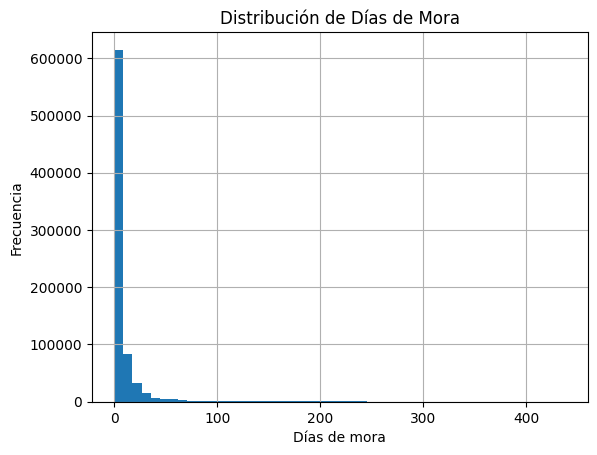

In [16]:
pagos['DiasMoraMovimiento'].hist(bins=50)
plt.title("Distribución de Días de Mora")
plt.xlabel("Días de mora")
plt.ylabel("Frecuencia")
plt.show()

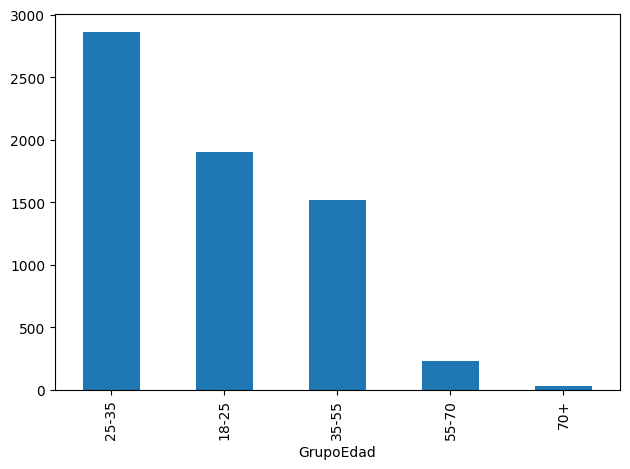

In [17]:
impago = pagos[pagos['DiasMoraMovimiento'] >= 180]

impago_edad = impago.merge(clientes[['PKCliente', 'Edad']], 
                           left_on='SKCliente', 
                           right_on='PKCliente')

bins = [18, 25, 35, 55, 70, float('inf')]
labels = ['18-25', '25-35', '35-55', '55-70', '70+']

impago_edad['GrupoEdad'] = pd.cut(impago_edad['Edad'], bins=bins, labels=labels, right=False)

impago_edad.groupby('GrupoEdad')['SKCliente'].count().sort_values(ascending=False).plot(kind='bar')
plt.tight_layout()
plt.show()

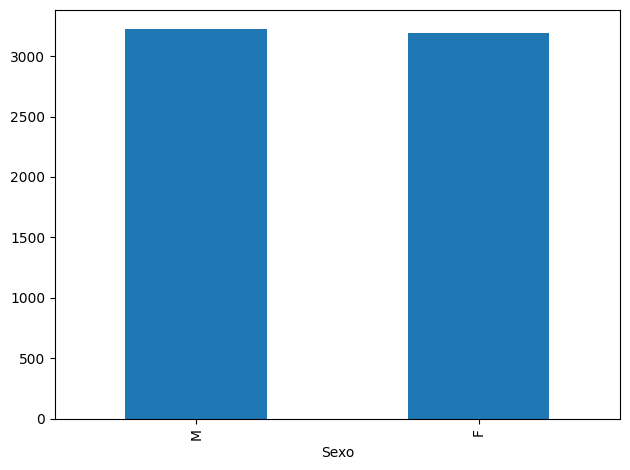

In [18]:
impago_sexo = impago.merge(clientes[['PKCliente', 'Sexo']], 
                           left_on='SKCliente', 
                           right_on='PKCliente')

impago_sexo.groupby('Sexo')['SKCliente'].count().sort_values(ascending=False).plot(kind='bar')
plt.tight_layout()
plt.show()

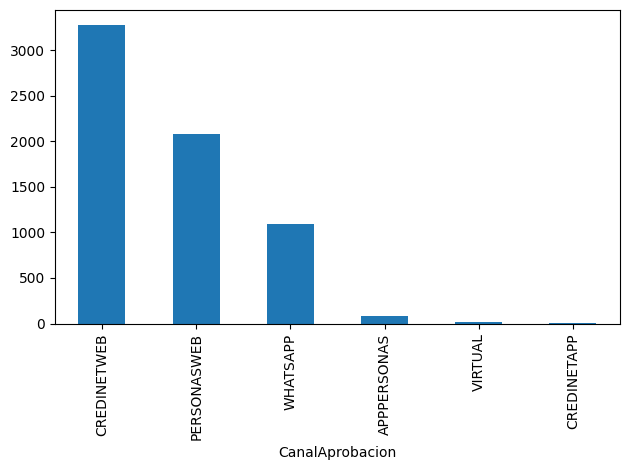

In [19]:
impago_canal = impago.merge(clientes[['PKCliente', 'CanalAprobacion']], 
                            left_on='SKCliente', 
                            right_on='PKCliente')

impago_canal.groupby('CanalAprobacion')['SKCliente'].count().sort_values(ascending=False).plot(kind='bar')
plt.tight_layout()
plt.show()

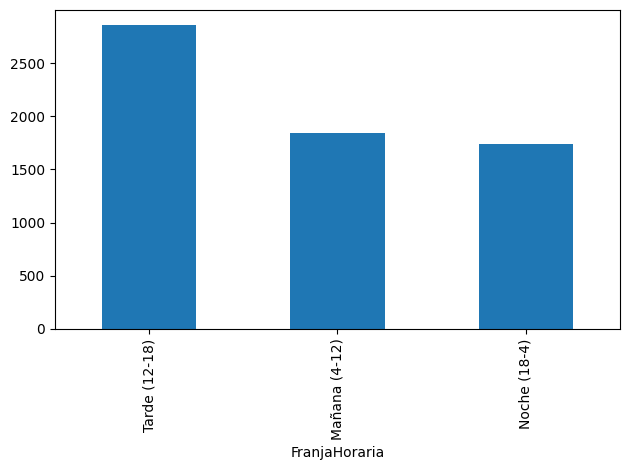

In [ ]:
impago['HoraTransaccion'] = pd.to_datetime(impago['HoraTransaccion'], format='mixed').dt.hour

impago['FranjaHoraria'] = pd.cut(impago['HoraTransaccion'], 
                                  bins=[4, 12, 18, 24], 
                                  labels=['Mañana (4-12)', 'Tarde (12-18)', 'Noche (18-4)'],
                                  right=False)

impago.groupby('FranjaHoraria')['SKCliente'].count().sort_values(ascending=False).plot(kind='bar')
plt.tight_layout()
plt.show()

In [21]:
pagos['DiasMoraMovimiento'].describe()

count    786671.000000
mean          9.145460
std          28.506454
min           0.000000
25%           0.000000
50%           1.000000
75%           7.000000
max         438.000000
Name: DiasMoraMovimiento, dtype: float64

La distribución de la mora presenta una alta concentración de valores en cero, lo que indica que la mayoría de los clientes cumple con sus pagos. Sin embargo, se observa una cola larga hacia la derecha, evidenciando la existencia de clientes con niveles elevados de mora, lo que sugiere la presencia de comportamientos de alto riesgo.

# **FASE 3: Data preparation** #
Transformar datos

Como tenemos que 1 cliente puede tener más de un pago en mora, solo se dejan los >=90

In [14]:
pagos = pagos[pagos['DiasMoraMovimiento'] >= 180]

In [15]:
pagos.head()

,SKCredito,SKCliente,SKFechaTransaccion,HoraTransaccion,NombreAlmacen,ValorPagadoTotal,DiasMoraMovimiento
32,46042093,4069854,20260224,13:32:30.0000000,PAGOS BOTON BANCOLOMBIA,723594.0,233
122,47554192,1356164,20260314,16:24:58.0000000,EFECTY,115927.0,211
188,42246227,746847,20260416,15:51:52.0000000,GANA,630057.0,368
243,43172799,3703525,20251030,09:31:44.0000000,PAGOS BOTON BANCOLOMBIA,218056.0,198
262,41913813,2355085,20260123,19:03:27.0000000,GANA,712012.0,205


In [98]:
pagos['SKFechaTransaccion'] = pd.to_datetime(pagos['SKFechaTransaccion'], format='%Y%m%d')

In [99]:
pagos.head()

,SKCredito,SKCliente,SKFechaTransaccion,HoraTransaccion,NombreAlmacen,ValorPagadoTotal,DiasMoraMovimiento
32,46042093,4069854,2026-02-24,13:32:30.0000000,PAGOS BOTON BANCOLOMBIA,723594.0,233
122,47554192,1356164,2026-03-14,16:24:58.0000000,EFECTY,115927.0,211
188,42246227,746847,2026-04-16,15:51:52.0000000,GANA,630057.0,368
243,43172799,3703525,2025-10-30,09:31:44.0000000,PAGOS BOTON BANCOLOMBIA,218056.0,198
262,41913813,2355085,2026-01-23,19:03:27.0000000,GANA,712012.0,205


**1. Unir tablas**

In [16]:
clientes.head()

,PKCliente,Sexo,Score,CanalAprobacion,FechaAprobacion,CiudadFrecuente,Edad,CupoTotal
0,1904418,M,760.0,PERSONASWEB,2021-02-22 12:27:27.3670000,MEDELLIN,39.0,3.000.000.000.000
1,4300739,F,624.0,PERSONASWEB,2021-03-31 16:29:03.9370000,"BOGOTA, D.C.",26.0,1.500.000.000.000
2,2303055,M,568.0,PERSONASWEB,2023-01-14 15:18:39.9430000,"BOGOTA, D.C.",24.0,3.000.000.000.000
3,222409,F,714.0,CREDINETWEB,2022-06-13 15:53:29.7070000,MEDELLIN,27.0,3.000.000.000.000
4,3468798,M,618.0,PERSONASWEB,2022-12-15 07:59:56.9530000,MEDELLIN,27.0,3.000.000.000.000


In [102]:
mora_por_cliente = (
    pagos
    .groupby('SKCliente')
    .apply(lambda x: x.loc[x['DiasMoraMovimiento'].idxmax(), ['DiasMoraMovimiento', 'SKFechaTransaccion']])
    .reset_index()
    .rename(columns={'SKCliente': 'PKCliente', 'SKFechaTransaccion': 'FechaAprobacionPago'})
)

clientes_mora = clientes.merge(mora_por_cliente, on='PKCliente', how='left')

clientes_mora['impago'] = (clientes_mora['DiasMoraMovimiento'] >= 180).astype(int)
clientes_mora['impago'] = clientes_mora['impago'].fillna(0).astype(int)

clientes_mora.head()

,PKCliente,Sexo,Score,CanalAprobacion,FechaAprobacion,CiudadFrecuente,Edad,CupoTotal,DiasMoraMovimiento,FechaAprobacionPago,impago
0,1904418,M,760.0,PERSONASWEB,2021-02-22 12:27:27.3670000,MEDELLIN,39.0,3.000.000.000.000,NaN,NaT,0
1,4300739,F,624.0,PERSONASWEB,2021-03-31 16:29:03.9370000,"BOGOTA, D.C.",26.0,1.500.000.000.000,NaN,NaT,0
2,2303055,M,568.0,PERSONASWEB,2023-01-14 15:18:39.9430000,"BOGOTA, D.C.",24.0,3.000.000.000.000,NaN,NaT,0
3,222409,F,714.0,CREDINETWEB,2022-06-13 15:53:29.7070000,MEDELLIN,27.0,3.000.000.000.000,NaN,NaT,0
4,3468798,M,618.0,PERSONASWEB,2022-12-15 07:59:56.9530000,MEDELLIN,27.0,3.000.000.000.000,NaN,NaT,0


Se llenan variables nulas destacables para el modelo 

In [104]:
clientes_mora['DiasMoraMovimiento'].fillna(0, inplace=True)
clientes_mora['Score'].fillna(0, inplace=True)
clientes_mora['Edad'].fillna(0, inplace=True)
clientes_mora['FechaAprobacionPago'] = clientes_mora['FechaAprobacionPago'].fillna(pd.Timestamp('1900-01-01'))

Las demás variables categoricas sin tanta relevancia se llenan con: "No se tiene info"

In [105]:
clientes_mora.fillna('Otro', inplace=True)

In [106]:
clientes_mora.head(5)

,PKCliente,Sexo,Score,CanalAprobacion,FechaAprobacion,CiudadFrecuente,Edad,CupoTotal,DiasMoraMovimiento,FechaAprobacionPago,impago
0,1904418,M,760.0,PERSONASWEB,2021-02-22 12:27:27.3670000,MEDELLIN,39.0,3.000.000.000.000,0.0,1900-01-01,0
1,4300739,F,624.0,PERSONASWEB,2021-03-31 16:29:03.9370000,"BOGOTA, D.C.",26.0,1.500.000.000.000,0.0,1900-01-01,0
2,2303055,M,568.0,PERSONASWEB,2023-01-14 15:18:39.9430000,"BOGOTA, D.C.",24.0,3.000.000.000.000,0.0,1900-01-01,0
3,222409,F,714.0,CREDINETWEB,2022-06-13 15:53:29.7070000,MEDELLIN,27.0,3.000.000.000.000,0.0,1900-01-01,0
4,3468798,M,618.0,PERSONASWEB,2022-12-15 07:59:56.9530000,MEDELLIN,27.0,3.000.000.000.000,0.0,1900-01-01,0


Se exporta el dataset como csv

In [107]:
clientes_mora.to_csv('clientes_mora.csv', index=False)

In [108]:
clientes_mora.head(5)

,PKCliente,Sexo,Score,CanalAprobacion,FechaAprobacion,CiudadFrecuente,Edad,CupoTotal,DiasMoraMovimiento,FechaAprobacionPago,impago
0,1904418,M,760.0,PERSONASWEB,2021-02-22 12:27:27.3670000,MEDELLIN,39.0,3.000.000.000.000,0.0,1900-01-01,0
1,4300739,F,624.0,PERSONASWEB,2021-03-31 16:29:03.9370000,"BOGOTA, D.C.",26.0,1.500.000.000.000,0.0,1900-01-01,0
2,2303055,M,568.0,PERSONASWEB,2023-01-14 15:18:39.9430000,"BOGOTA, D.C.",24.0,3.000.000.000.000,0.0,1900-01-01,0
3,222409,F,714.0,CREDINETWEB,2022-06-13 15:53:29.7070000,MEDELLIN,27.0,3.000.000.000.000,0.0,1900-01-01,0
4,3468798,M,618.0,PERSONASWEB,2022-12-15 07:59:56.9530000,MEDELLIN,27.0,3.000.000.000.000,0.0,1900-01-01,0


# **FASE 4: Modelado** #

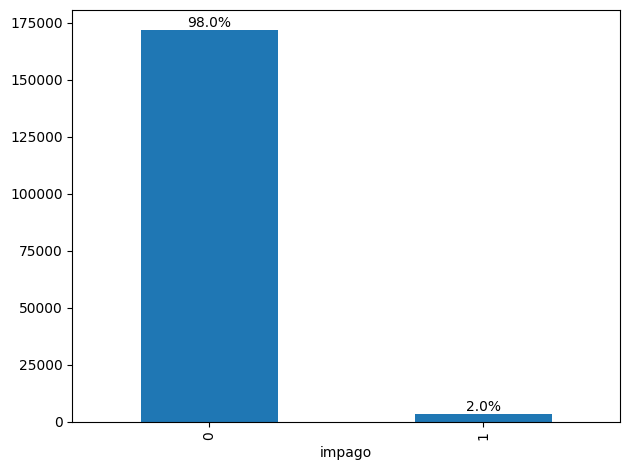

In [109]:
conteo = clientes_mora['impago'].value_counts()
total = conteo.sum()

ax = conteo.plot(kind='bar')

for p in ax.patches:
    pct = f'{p.get_height() / total * 100:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

Contamos con un dataset desbalanceado

Ingenieria de caracteristicas

¿Que tan relevante es el score?

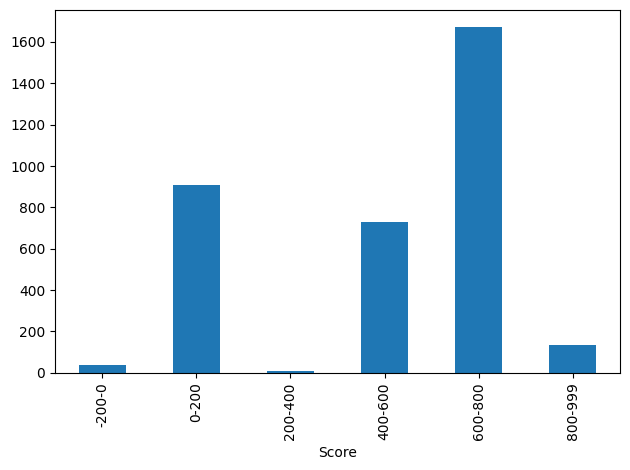

In [ ]:
bins = [-200, 0, 200, 400, 600, 800, 999]
labels = ['-200-0','0-200', '200-400', '400-600', '600-800', '800-999']

clientes_mora[clientes_mora['impago'] == 1]['Score'].pipe(
    pd.cut, bins=bins, labels=labels, right=False
).value_counts().sort_index().plot(kind='bar')

plt.tight_layout()
plt.show()

Que tan importante es la fecha

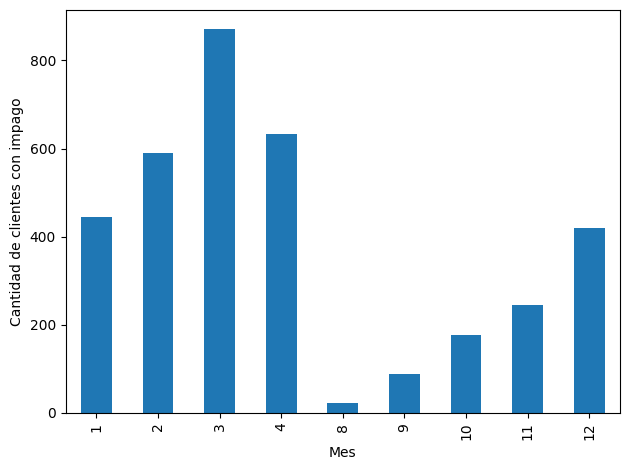

In [114]:
clientes_mora[clientes_mora['impago'] == 1].groupby(clientes_mora['FechaAprobacionPago'].dt.month)['PKCliente'].count().plot(kind='bar')
plt.xlabel('Mes')
plt.ylabel('Cantidad de clientes con impago')
plt.tight_layout()
plt.show()

Variables numericas

In [110]:
clientes_mora['CupoTotal'] = clientes_mora['CupoTotal'].str.replace('.', '', regex=False).astype(float)

Normalización de score y CanalAprobación

In [115]:
clientes_mora['CupoTotal'] = pd.to_numeric(clientes_mora['CupoTotal'], errors='coerce')
clientes_mora['DiasMoraMovimiento'] = pd.to_numeric(clientes_mora['DiasMoraMovimiento'], errors='coerce')
bins = [-200, 0, 200, 400, 600, 800, 999,1000]
labels = [1, 2, 3, 4, 5,6,7]
clientes_mora['Score_rango'] = pd.cut(clientes_mora['Score'], bins=bins, labels=labels, right=False).astype(float)

tasa_impago = clientes_mora.groupby('CanalAprobacion')['impago'].mean()
clientes_mora['Canal_tasa_impago'] = clientes_mora['CanalAprobacion'].map(tasa_impago)

clientes_mora['Mes_pago'] = clientes_mora['FechaAprobacionPago'].dt.month

clientes_mora.head()

,PKCliente,Sexo,Score,CanalAprobacion,FechaAprobacion,CiudadFrecuente,Edad,CupoTotal,DiasMoraMovimiento,FechaAprobacionPago,impago,Score_rango,Canal_tasa_impago,Mes_pago
0,1904418,M,760.0,PERSONASWEB,2021-02-22 12:27:27.3670000,MEDELLIN,39.0,3.000000e+12,0.0,1900-01-01,0,5.0,0.021623,1
1,4300739,F,624.0,PERSONASWEB,2021-03-31 16:29:03.9370000,"BOGOTA, D.C.",26.0,1.500000e+12,0.0,1900-01-01,0,5.0,0.021623,1
2,2303055,M,568.0,PERSONASWEB,2023-01-14 15:18:39.9430000,"BOGOTA, D.C.",24.0,3.000000e+12,0.0,1900-01-01,0,4.0,0.021623,1
3,222409,F,714.0,CREDINETWEB,2022-06-13 15:53:29.7070000,MEDELLIN,27.0,3.000000e+12,0.0,1900-01-01,0,5.0,0.017609,1
4,3468798,M,618.0,PERSONASWEB,2022-12-15 07:59:56.9530000,MEDELLIN,27.0,3.000000e+12,0.0,1900-01-01,0,5.0,0.021623,1


Exportamos dataset para modelar

In [50]:
clientes_mora.to_csv('clientes_mora_modelar.csv', index=False)

Seleccionamos técnicas de modelado

XGBClassifier

Oversampling

In [116]:
# 1. Variables predictoras y objetivo
X = clientes_mora[['Edad', 'CupoTotal', 'Score_rango','CiudadFrecuente', 'Canal_tasa_impago', 'Mes_pago']]
y = clientes_mora['impago']

# 2. Convertir variables categóricas
X = pd.get_dummies(X, columns=['CiudadFrecuente'])

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Aplicar Oversampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# 5. Entrenar el modelo
modelo_xgb = XGBClassifier(n_estimators=100, random_state=42)
modelo_xgb.fit(X_train_ros, y_train_ros)

# 6. Evaluar el modelo
y_pred = modelo_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     34429
           1       0.70      0.87      0.78       678

    accuracy                           0.99     35107
   macro avg       0.85      0.93      0.89     35107
weighted avg       0.99      0.99      0.99     35107



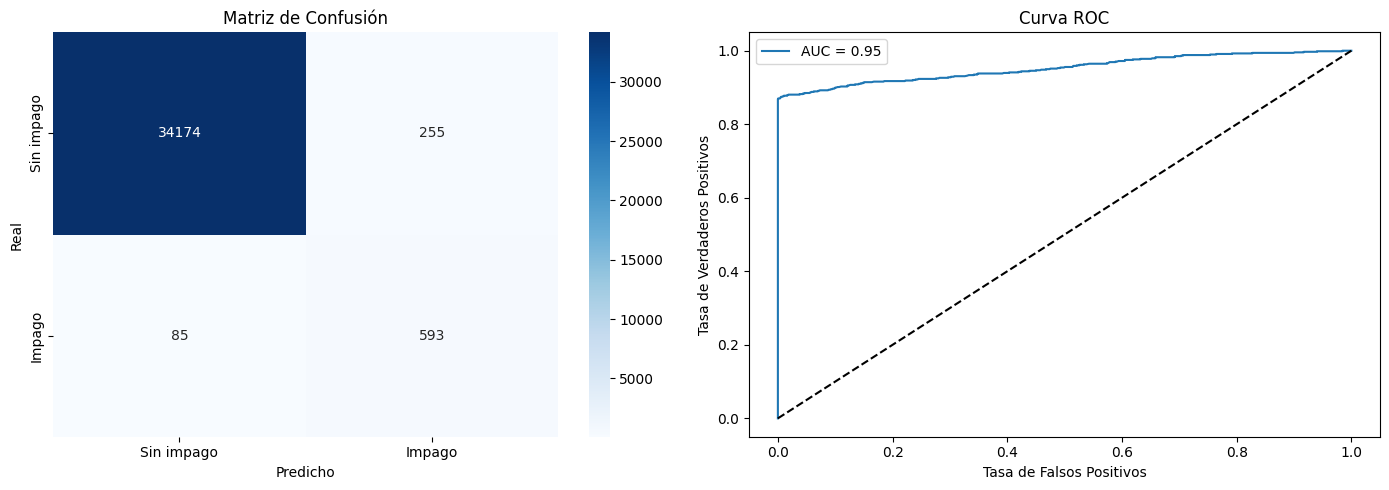

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sin impago', 'Impago'],
            yticklabels=['Sin impago', 'Impago'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

y_prob = modelo_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend()

plt.tight_layout()
plt.show()

RandomForest

Oversampling

In [120]:
# 1. Variables predictoras y objetivo
X = clientes_mora[['Edad', 'CupoTotal', 'Score_rango','CiudadFrecuente', 'Canal_tasa_impago', 'Mes_pago']]
y = clientes_mora['impago']

# 2. Convertir variables categóricas
X = pd.get_dummies(X, columns=['CiudadFrecuente'])

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Aplicar Oversampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# 5. Entrenar el modelo
rangom_forest_modelo = RandomForestClassifier(n_estimators=100, random_state=42)
rangom_forest_modelo.fit(X_train_ros, y_train_ros)

# 6. Evaluar el modelo
y_pred = rangom_forest_modelo.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     34429
           1       0.38      0.88      0.53       678

    accuracy                           0.97     35107
   macro avg       0.69      0.93      0.76     35107
weighted avg       0.99      0.97      0.98     35107



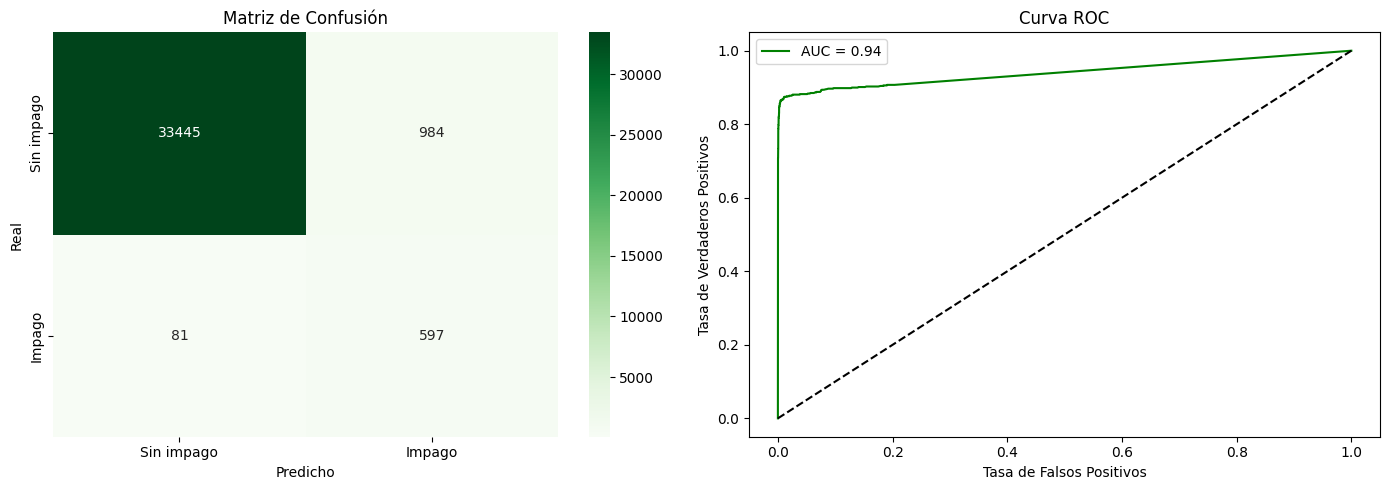

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Sin impago', 'Impago'],
            yticklabels=['Sin impago', 'Impago'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

y_prob = rangom_forest_modelo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='green', label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend()

plt.tight_layout()
plt.show()

# **FASE 5: Evaluacion** #

Variables con mayor peso para el modelo

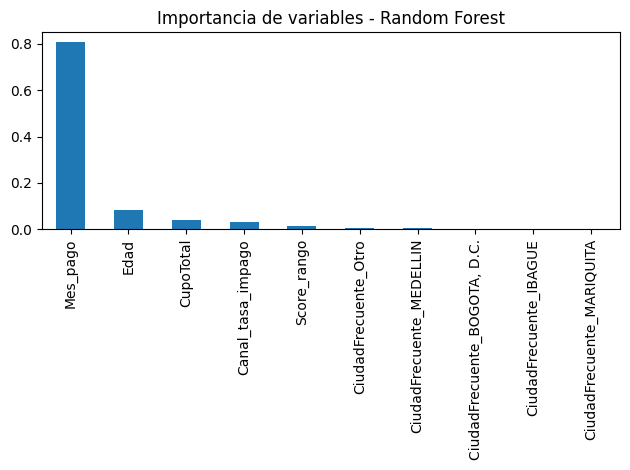

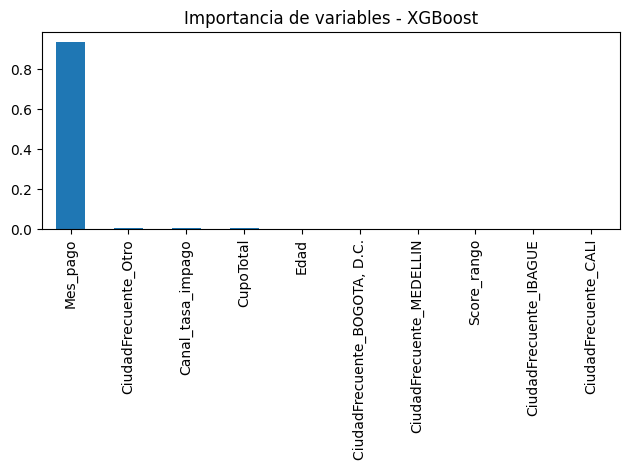

In [122]:
# Random Forest
importancias_rf = pd.Series(rangom_forest_modelo.feature_importances_, index=X_train.columns)
importancias_rf.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Importancia de variables - Random Forest')
plt.tight_layout()
plt.show()

# XGBoost
importancias_xgb = pd.Series(modelo_xgb.feature_importances_, index=X_train.columns)
importancias_xgb.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Importancia de variables - XGBoost')
plt.tight_layout()
plt.show()

In [123]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rangom_forest_modelo, X, y, cv=skf, scoring='roc_auc')
print(f'AUC promedio: {scores.mean():.3f} (+/- {scores.std():.3f})')

AUC promedio: 0.944 (+/- 0.006)


El modelo es capaz de distinguir correctamente entre un cliente con impago y uno sin impago el 94.4% de las veces.

In [124]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo_xgb,X, y, cv=skf, scoring='roc_auc')
print(f'AUC promedio: {scores.mean():.3f} (+/- {scores.std():.3f})')

AUC promedio: 0.955 (+/- 0.005)


El modelo es capaz de distinguir correctamente entre un cliente con impago y uno sin impago el 95.5% de las veces.

Comparación de matrices de confusión de los modelos

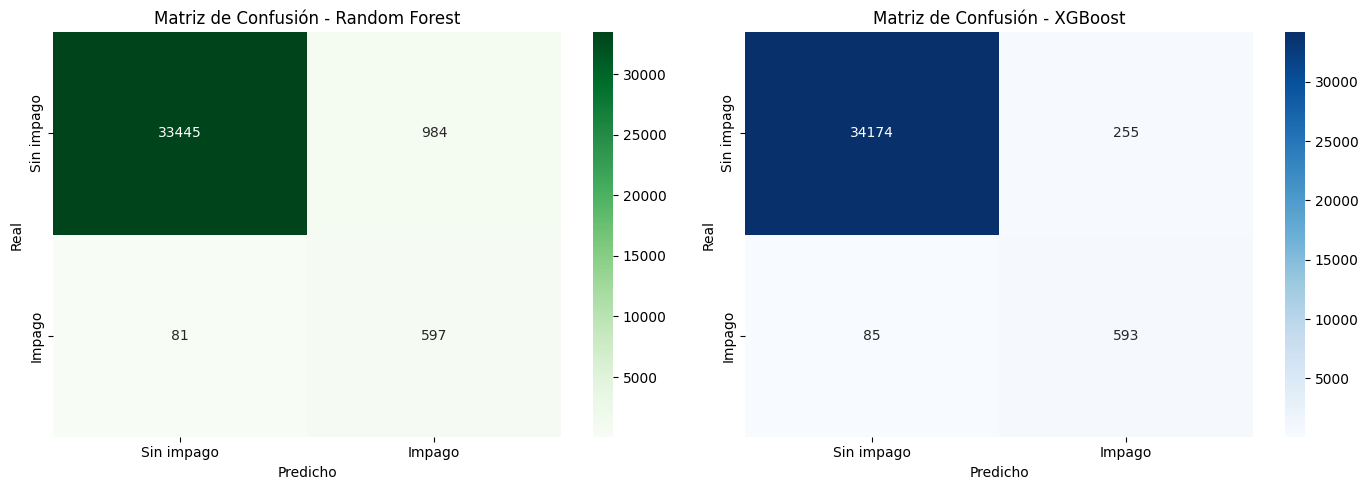

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, rangom_forest_modelo.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Sin impago', 'Impago'],
            yticklabels=['Sin impago', 'Impago'])
axes[0].set_title('Matriz de Confusión - Random Forest')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# XGBoost
cm_xgb = confusion_matrix(y_test, modelo_xgb.predict(X_test))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sin impago', 'Impago'],
            yticklabels=['Sin impago', 'Impago'])
axes[1].set_title('Matriz de Confusión - XGBoost')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()